Trains a FFNN on SBERT-sentence embeddings

In [1]:
# Load dataset
from local_utilities.dataset import get_dataset_sbert_train, get_dataset_sbert_validation
X_train, y_train = get_dataset_sbert_train()
X_val, y_val = get_dataset_sbert_validation()

[nltk_data] Downloading package punkt_tab to /home/tobias/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
/home/tobias/.pyenv/versions/genai/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Get device
from local_utilities.gpu import get_gpu
device = get_gpu()

In [3]:
X_train = X_train.to(device)
y_train = y_train.to(device)
X_val = X_val.to(device)
y_val = y_val.to(device)

In [4]:
from local_utilities.ffnn import FFNN
model = FFNN(X_train.shape[1]).to(device)

In [5]:
# Weight data
import torch
from torch.utils.data import WeightedRandomSampler

class_counts = torch.bincount(y_train)
class_weights = 1. / class_counts
sample_weights = class_weights[y_train]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

In [6]:
# Define loss function
from torch.nn import CrossEntropyLoss
criterion = CrossEntropyLoss()

In [7]:
# Define optimizer
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr=2e-4, weight_decay=5e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=2)

In [8]:
# Define dataset for training
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)

In [9]:
# Train FFNN
num_epochs = 32
train_losses = []
val_losses = []
state_dicts = []

for epoch in range(num_epochs):
    # Train model
    model.train()
    train_loss = 0.0

    # Iterate over training data
    for xb, yb in train_loader:
        # Reset gradients
        optimizer.zero_grad()
        
        # Compute loss
        outputs = model(xb)
        loss = criterion(outputs, yb)
        
        # Apply loss
        loss.backward()
        
        # Step forward
        optimizer.step()
        
        # Add loss
        train_loss += loss.item()
        
    # Statistics
    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # Validate model
    model.eval()
    val_loss = 0.0
    
    # Disable gradient tracking
    with torch.no_grad():
        # Predict yet unseen data
        logits = model(X_val)
        preds = torch.argmax(logits, dim=1)
        
        # Compute metrics
        accuracy = (preds == y_val).float().mean().item()
        val_loss = criterion(logits, y_val).item()
        
    # We can directly append the loss because we use all validation data at once
    val_losses.append(val_loss)

    # Scheduler step
    scheduler.step(val_loss)
    
    # Append current model state to list of states
    state_dicts.append(model.state_dict())
    
    # Show current data
    print(f"Epoch {epoch + 1}/{num_epochs}: "
          f"Train loss: {train_loss:.4f} | "
          f"Val loss: {val_loss:.4f} | "
          f" test accuracy: {accuracy:.4f}")
    

Epoch 1/32: Train loss: 0.3342 | Val loss: 0.2789 |  test accuracy: 0.8754
Epoch 2/32: Train loss: 0.2980 | Val loss: 0.2927 |  test accuracy: 0.8688
Epoch 3/32: Train loss: 0.2935 | Val loss: 0.2647 |  test accuracy: 0.8819
Epoch 4/32: Train loss: 0.2927 | Val loss: 0.2882 |  test accuracy: 0.8710
Epoch 5/32: Train loss: 0.2902 | Val loss: 0.2644 |  test accuracy: 0.8824
Epoch 6/32: Train loss: 0.2888 | Val loss: 0.2645 |  test accuracy: 0.8817
Epoch 7/32: Train loss: 0.2878 | Val loss: 0.2663 |  test accuracy: 0.8811
Epoch 8/32: Train loss: 0.2872 | Val loss: 0.2709 |  test accuracy: 0.8795
Epoch 9/32: Train loss: 0.2789 | Val loss: 0.2624 |  test accuracy: 0.8827
Epoch 10/32: Train loss: 0.2780 | Val loss: 0.2675 |  test accuracy: 0.8801
Epoch 11/32: Train loss: 0.2775 | Val loss: 0.2706 |  test accuracy: 0.8799
Epoch 12/32: Train loss: 0.2787 | Val loss: 0.2605 |  test accuracy: 0.8829
Epoch 13/32: Train loss: 0.2780 | Val loss: 0.2705 |  test accuracy: 0.8803
Epoch 14/32: Train lo

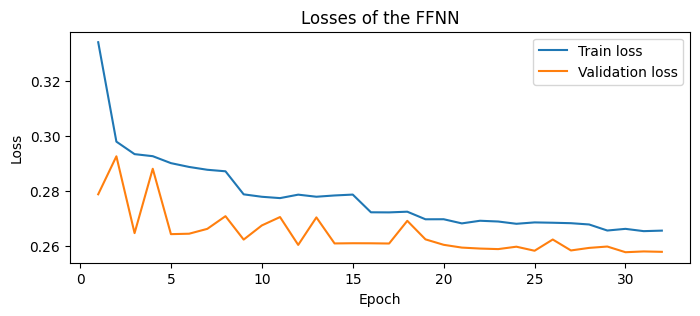

In [10]:
import matplotlib.pyplot as plt

x = [i + 1 for i in range(num_epochs)]

plt.figure(figsize=(8, 3))
plt.plot(x, train_losses, label="Train loss")
plt.plot(x, val_losses, label="Validation loss")
plt.legend()
plt.title("Losses of the FFNN")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [11]:
import numpy as np

losses = np.array(val_losses)
min_loss = np.argmin(val_losses)
print(f"The lowest validation loss was seen in epoch {min_loss+1}: {losses[min_loss]:.4f}")

The lowest validation loss was seen in epoch 30: 0.2578


In [12]:
# Store best model
from local_utilities.directory import get_ffnn_path
torch.save(state_dicts[min_loss], get_ffnn_path())